# ERA5 timeseries access from CDS using xcube

This notebook provides a walk-through demonstrating how to use xcube and the xcube Climate Data Store (CDS) plugin to read and explore temperature time series from ERA5 from the CDS.

Before using this notebook, ensure that you have set up xcube, the CDS plugin, and Jupyter Lab as described in the [Ex0-CDS-store-Setup](./Ex0-CDS-store-setup.ipynb) notebook.

First, we import some necessary libraries.

In [1]:
from xcube.core.store import new_data_store

Create a CDS data store object. The optional `normalize_names` parameter specifies that variable names in returned data cubes will be converted to legal Python identifiers, if required.

In [2]:
cds_store = new_data_store("cds", normalize_names=True)

Find out which datasets are available from this store. We get a list of tuples; the first member of each tuple is the data ID, and the second member is a short description of the dataset. We pick [ERA5 hourly time-series data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview).


In [3]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-land',
 'reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels-timeseries',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-soil-moisture:root-zone-volumetric:daily',
 'satellite-soil-moisture:root-zone-volumetric:10-day',
 'satellite-soil-moisture:root-zone-volumetric:monthly',
 'satellite-soil-moisture:freeze-thaw:daily',
 'satellite-sea-ice-t

In [4]:
data_id = 'reanalysis-era5-single-levels-timeseries'

Let's see what parameters we can specify when opening the dataset. Three are listed as required parameters: `time_range`, `location`, and `variable_names`. The enumeration in `properties → variable_names → items` lists the variables we can request. 

In [5]:
cds_store.get_open_data_params_schema(data_id)

Next, we open the data cube from the store. We can request any number of variables. Here, we select all available variables. We define the **location** at which the timeseries is evaluated. Note that the ERA5 reanalysis dataset has a resolution of 0.25°, so the location will be rounded to the nearest grid point. For the `time range`, we select the years 1940 to 2025. Dates are specified in ISO-8601 format.

In [7]:
%%time
cube = cds_store.open_data(
    data_id,
    variable_names=[
        '2m_temperature',
        '2m_dewpoint_temperature',
        'skin_temperature',
        'sea_surface_temperature',
        '10m_u_component_of_wind',
        '10m_v_component_of_wind',
        '100m_u_component_of_wind',
        '100m_v_component_of_wind',
        '10m_wind_gust_since_previous_post_processing',
        'surface_pressure',
        'mean_sea_level_pressure',
        'total_precipitation',
        'surface_solar_radiation_downwards',
        'total_sky_direct_solar_radiation_at_surface',
        'surface_thermal_radiation_downwards',
        'total_cloud_cover',
        'cloud_base_height',
        'boundary_layer_height',
        'significant_height_of_combined_wind_waves_and_swell',
        'mean_wave_period',
        'mean_wave_direction'
    ],
    location=[10.1, 53.55],
    time_range=["1940-01-01", "2025-12-31"],
)

xcube-cds version 1.4.2.dev0
2026-07-09 12:31:20,088 INFO Request ID is d1c27cf7-1397-4701-b541-56891355f5af
2026-07-09 12:31:20,358 INFO status has been updated to accepted
2026-07-09 12:31:41,706 INFO status has been updated to running
2026-07-09 12:32:10,369 INFO status has been updated to successful


CPU times: user 331 ms, sys: 288 ms, total: 619 ms
Wall time: 55.3 s


/home/konstantin/bc_kon/01_coding/01_github/xcube-cds/xcube_cds/utils.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(
/home/konstantin/bc_kon/01_coding/01_github/xcube-cds/xcube_cds/utils.py:41: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.open_mfdataset(


Show a summary of the dataset in the notebook.

In [8]:
cube

<xarray.Dataset> Size: 69MB
Dimensions:    (time: 753888)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:00:00
    latitude   float64 8B 53.5
    longitude  float64 8B 10.0
Data variables: (12/21)
    mwd        (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    mwp        (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    swh        (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    u100       (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    v100       (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    u10        (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    ...         ...
    sp         (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    ssrd       (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    strd       (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    tcc        (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    tp         (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
    fdir       (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-05T05:51 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

Then we can plot the full temperature timeseries as shown below.

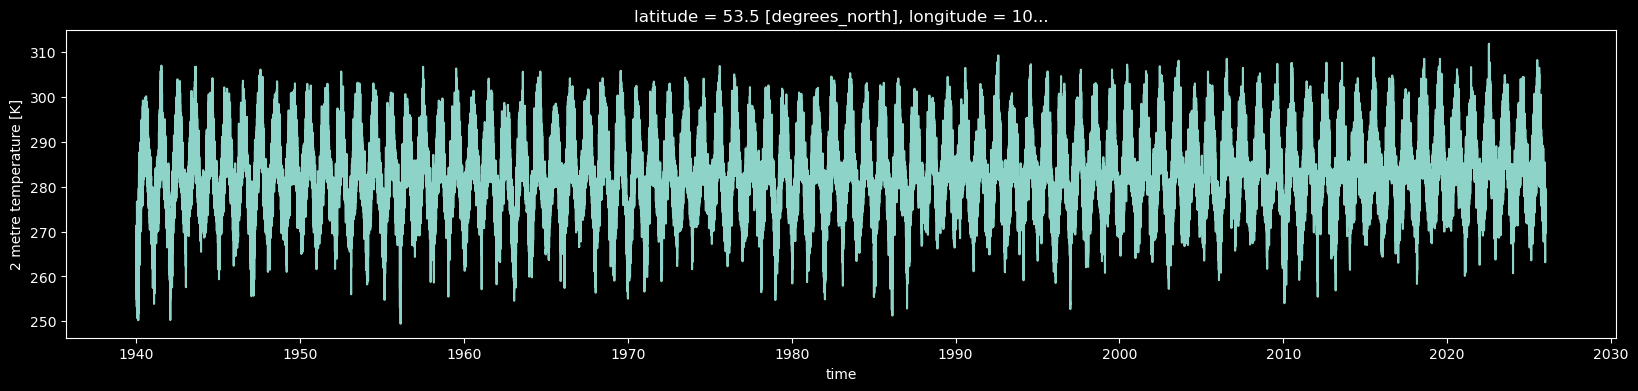

In [9]:
cube.t2m.plot(figsize=(20, 4))